# MODELIZACIÓN REGRESIÓN LOSS GIVEN DEFAULT

## IMPORTAR PAQUETES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
import os
from pathlib import Path
import joblib

from sklearn.base import clone
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Desactivar notación científica
pd.set_option('display.float_format', lambda x: '%.3f' % x)
np.set_printoptions(suppress=True)

# Cargar variables de entorno
load_dotenv()

SEMILLA = 42

print("✅ Librerías importadas correctamente")


✅ Librerías importadas correctamente


## IMPORTAR LOS DATOS

Usamos el tablón **sin transformar** (variables crudas + target). El preprocesador se ajusta más abajo,
dentro del pipeline, solo con datos de entrenamiento: así la validación interna no se contamina con
estadísticos (medias, categorías) calculados sobre todo el conjunto, incluida la propia validación.

In [2]:
df = pd.read_pickle('../02_datos/03_Entrenamiento/df_tablon_lgd_sin_transformar.pkl')
print(df.shape)
df.target_lgd.describe()


(16568, 16)


count   16568.000
mean        0.889
std         0.136
min         0.000
25%         0.858
50%         0.897
75%         1.000
max         1.000
Name: target_lgd, dtype: float64

In [3]:
x = df.drop(columns='target_lgd')
y = df.target_lgd


## MODELIZAR

### Reservar el dataset de validación

`random_state`: la partición es siempre la misma, así los resultados se pueden reproducir.

In [4]:
train_x, val_x, train_y, val_y = train_test_split(x, y, test_size=0.3, random_state=SEMILLA)


### Crear el pipe: preprocesador + escalado + algoritmo

Cargamos el preprocesador diseñado en la fase de transformación y lo **clonamos**: `clone` copia su
configuración pero no lo aprendido. Así, en cada fold de la validación cruzada se ajusta solo con los
datos de entrenamiento de ese fold y el fold de evaluación nunca influye en el escalado ni en las categorías.

Ridge y Lasso necesitan las variables en la misma escala, por eso llevan `StandardScaler`. HGB no lo
necesita: para ese algoritmo el escalado se deja en `'passthrough'`.

In [5]:
pipe = Pipeline([
    ('preprocesador', clone(joblib.load('../05_modelos/preprocesador.joblib'))),
    ('escalado', StandardScaler()),
    ('algoritmo', Ridge()),
])

grid = [
        {'escalado': [StandardScaler()],
         'algoritmo': [Ridge()],
         'algoritmo__alpha': np.logspace(-3, 2, 11)},

        {'escalado': [StandardScaler()],
         'algoritmo': [Lasso(max_iter=5000)],
         'algoritmo__alpha': np.logspace(-3, 2, 11)},

        {'escalado': ['passthrough'],
         'algoritmo': [HistGradientBoostingRegressor(loss='absolute_error', min_samples_leaf=50, random_state=SEMILLA)],
         'algoritmo__learning_rate': [0.01, 0.025, 0.05, 0.1],
         'algoritmo__max_iter': [50, 100, 200],
         'algoritmo__max_depth': [5, 10, 20],
         'algoritmo__l2_regularization': [0, 0.25, 0.5, 0.75, 1]}
       ]


### Optimizar los hiperparámetros con grid search

`KFold` con `shuffle=True` y semilla hace los 5 folds reproducibles. A diferencia de PD, esto es
regresión: no hace falta estratificar por clase.

In [6]:
cv = KFold(n_splits=5, shuffle=True, random_state=SEMILLA)

grid_search = GridSearchCV(estimator=pipe,
                           param_grid=grid,
                           cv=cv,
                           scoring='neg_mean_absolute_error',
                           verbose=0,
                           n_jobs=-1)

grid_search.fit(train_x, train_y)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...o', Ridge())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'algoritmo': [Ridge()], 'algoritmo__alpha': array([ 0.00...100. ]), 'escalado': [StandardScaler()]}, {'algoritmo': [Lasso(max_iter=5000)], 'algoritmo__alpha': array([ 0.00...100. ]), 'escalado': [StandardScaler()]}, ...]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of

In [7]:
resultados = pd.DataFrame(grid_search.cv_results_)
resultados['algoritmo'] = resultados['param_algoritmo'].apply(lambda a: type(a).__name__)
resultados['MAE_cv'] = -resultados['mean_test_score']
resultados['parametros'] = resultados['params'].apply(
    lambda p: {k.split('__')[-1]: v for k, v in p.items() if k not in ('algoritmo', 'escalado')})

top10 = resultados.sort_values('rank_test_score').head(10)[
    ['algoritmo', 'parametros', 'MAE_cv', 'std_test_score', 'rank_test_score']
].reset_index(drop=True)
top10


,algoritmo,parametros,MAE_cv,std_test_score,rank_test_score
0,HistGradientBoostingRegressor,"{'l2_regularization': 0.75, 'learning_rate': 0...",0.089,0.003,1
1,HistGradientBoostingRegressor,"{'l2_regularization': 0.75, 'learning_rate': 0...",0.089,0.003,2
2,HistGradientBoostingRegressor,"{'l2_regularization': 0.5, 'learning_rate': 0....",0.089,0.003,3
3,HistGradientBoostingRegressor,"{'l2_regularization': 0.25, 'learning_rate': 0...",0.089,0.003,4
4,HistGradientBoostingRegressor,"{'l2_regularization': 0.25, 'learning_rate': 0...",0.089,0.003,5
5,HistGradientBoostingRegressor,"{'l2_regularization': 0, 'learning_rate': 0.01...",0.089,0.003,6
6,HistGradientBoostingRegressor,"{'l2_regularization': 0.25, 'learning_rate': 0...",0.089,0.002,7
7,HistGradientBoostingRegressor,"{'l2_regularization': 1, 'learning_rate': 0.02...",0.089,0.003,8
8,HistGradientBoostingRegressor,"{'l2_regularization': 0.75, 'learning_rate': 0...",0.089,0.003,9
9,HistGradientBoostingRegressor,"{'l2_regularization': 0.75, 'learning_rate': 0...",0.089,0.003,10


### Modelo final

`GridSearchCV` ya reentrena la mejor configuración sobre todo el train (`refit=True`). Usamos
`best_estimator_` directamente en lugar de instanciar el modelo a mano con parámetros copiados.

In [8]:
modelo = grid_search.best_estimator_
grid_search.best_params_


{'algoritmo': HistGradientBoostingRegressor(loss='absolute_error', min_samples_leaf=50,
                               random_state=42),
 'algoritmo__l2_regularization': 0.75,
 'algoritmo__learning_rate': 0.01,
 'algoritmo__max_depth': 5,
 'algoritmo__max_iter': 200,
 'escalado': 'passthrough'}

## EVALUAR

### Predecir sobre validación

In [9]:
pred = modelo.predict(val_x)


Corregimos los máximos y mínimos.

In [10]:
pred = np.where(pred < 0, 0, pred)
pred = np.where(pred > 1, 1, pred)


### Baseline: predecir siempre la mediana

Un MAE no dice nada por sí solo. Lo comparamos con un modelo trivial, `DummyRegressor(strategy='median')`,
que siempre predice la mediana de `target_lgd` en train. Si el modelo no mejora claramente esta referencia,
no está aportando valor.

In [11]:
baseline = DummyRegressor(strategy='median').fit(train_x, train_y)
pred_baseline = baseline.predict(val_x)

mae_modelo = mean_absolute_error(val_y, pred)
mae_baseline = mean_absolute_error(val_y, pred_baseline)

comparacion = pd.DataFrame({
    'MAE': [mae_modelo, mae_baseline],
    'mejora_vs_baseline': [1 - mae_modelo / mae_baseline, 0.0],
}, index=['modelo', 'baseline (mediana)'])
comparacion


,MAE,mejora_vs_baseline
modelo,0.087,0.006
baseline (mediana),0.088,0.000


**Lectura**: gana HistGradientBoosting (`learning_rate` 0,01, `max_depth` 5, 200 iteraciones, `l2_regularization` 0,75) con un MAE de validación cruzada de 0,089 (±0,003), y las 10 mejores combinaciones empatan en 0,089. En la validación interna el MAE del modelo es 0,087 frente a 0,088 de predecir siempre la mediana: una mejora de apenas el 0,6%. Con estas variables el modelo prácticamente no aprende nada sobre la LGD más allá de su valor típico. El siguiente paso es revisar las variables o el enfoque (por ejemplo, un modelo en dos etapas), no seguir ajustando hiperparámetros.

## REPORTING DEL MODELO

In [12]:
check_validacion = pd.DataFrame({'lgd_real': val_y, 'lgd_pred': pred})
check_validacion


,lgd_real,lgd_pred
id_cliente,,
13468751,0.523,0.897
40380300,1.000,0.899
70700177,0.936,0.902
74533033,0.861,0.893
8875309,1.000,0.896
...,...,...
125768406,0.863,0.890
99798943,0.550,0.918
60265715,1.000,0.903


Graficamos los residuos contra el valor **predicho**, no contra el valor real. Si se grafican contra el
real, el residuo (`real - predicho`) incluye al propio real de ambos lados de la resta: cuando el real es
alto el residuo tiende a ser positivo y cuando es bajo tiende a ser negativo, lo que dibuja una pendiente
positiva aunque el modelo no tenga ningún sesgo sistemático. Contra el predicho esa correlación artificial
desaparece y el gráfico muestra si el error depende del nivel de la predicción (heterocedasticidad) o es
una nube dispersa alrededor de 0, que es lo esperable en un buen ajuste.

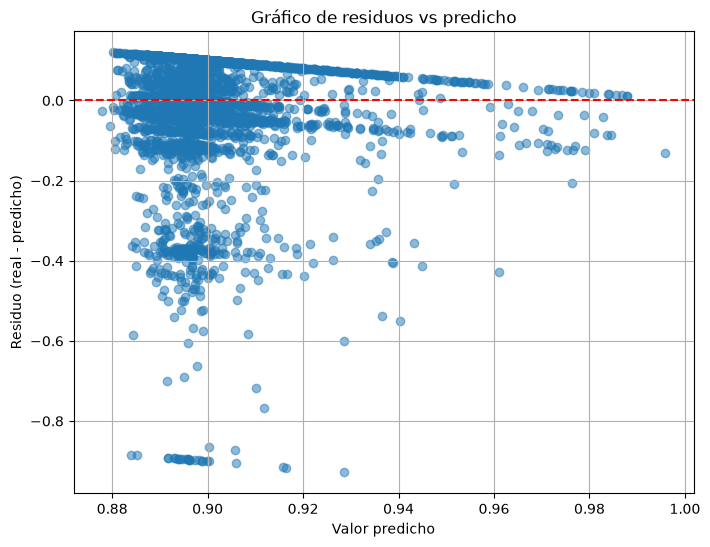

In [13]:
residuos = val_y - pred
plt.figure(figsize=(8, 6))
plt.scatter(pred, residuos, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Valor predicho')
plt.ylabel('Residuo (real - predicho)')
plt.title('Gráfico de residuos vs predicho')
plt.grid()
plt.show()


**Lectura**: no hay pendiente (correlación residuo–predicho −0,03) y la media del residuo es la misma en los tres tercios de predicción (≈ −0,01). Pero las predicciones van solo de 0,88 a 0,92 (percentiles 5 a 95), mientras que la LGD real va de 0,57 a 1,00: el modelo asigna casi la misma LGD a todos los préstamos.

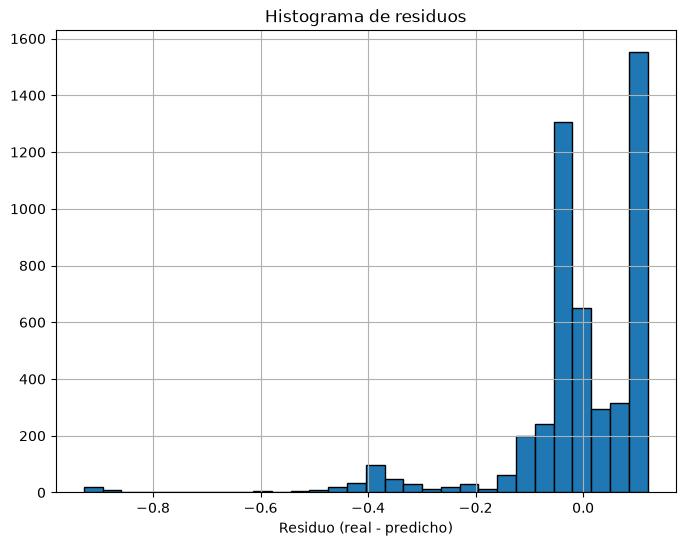

In [14]:
plt.figure(figsize=(8, 6))
plt.hist(residuos, bins=30, edgecolor='k')
plt.xlabel('Residuo (real - predicho)')
plt.title('Histograma de residuos')
plt.grid()
plt.show()


**Lectura**: el 66% de los residuos cae dentro de ±0,10 porque la mayoría de las LGD reales están cerca de 0,9, no porque el modelo discrimine. La cola izquierda (percentil 5 en −0,34) corresponde a préstamos con mucho recupero: en el 6,8% de los casos con LGD real menor a 0,7, el modelo sobrestima la pérdida en 0,41 de media.

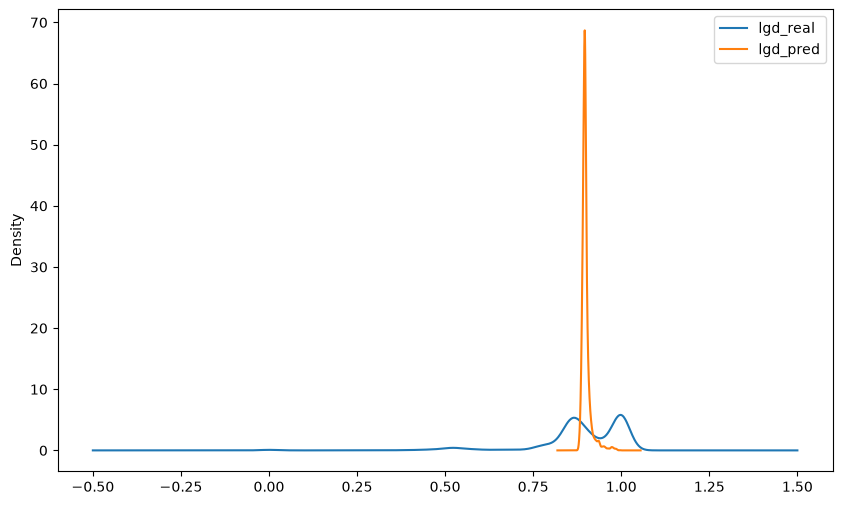

In [15]:
check_validacion.plot.density(figsize=(10, 6));


**Lectura**: las predicciones forman un pico angosto alrededor de 0,89, mientras que la realidad tiene dos masas, una cerca de 0,86 y otra en 1,0 (30,5% de los casos), más una cola de recuperos altos. El modelo no separa ninguno de esos grupos.